In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_kyiv_encoded = pd.read_csv('Kyiv_ML.csv')

X = df_kyiv_encoded.drop(columns=['price', 'is_middle_floor'])
y = df_kyiv_encoded['price']

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальної вибірки: {X_train.shape[0]} квартир")
print(f"Розмір тестової вибірки: {X_test.shape[0]} квартир")

Розмір навчальної вибірки: 5418 квартир
Розмір тестової вибірки: 1355 квартир


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

results_list = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results_list.append({
        "Модель": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

df_results = pd.DataFrame(results_list)

df_results = df_results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("\n ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ:")
print(df_results)


 ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ:
             Модель  R2 Score  MAE ($)  RMSE ($)
0          CatBoost    0.5572   305.34    407.34
1          LightGBM    0.5514   305.50    410.02
2     Random Forest    0.5446   305.40    413.12
3  Ridge Regression    0.4107   370.01    469.93


In [4]:
from sklearn.model_selection import GridSearchCV


lgbm = LGBMRegressor(random_state=42, verbose=-1)

param_grid = {
    'n_estimators': [100, 200, 300, 500],    
    'learning_rate': [0.01, 0.03, 0.05, 0.1], 
    'max_depth': [4, 6, 8, -1], 
    'num_leaves': [15, 31, 63]
}

print("⏳ Запуск GridSearchCV для LightGBM... Це може зайняти 1-2 хвилини.")

grid_search = GridSearchCV(
    estimator=lgbm, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1     
)

grid_search.fit(X_train, y_train)

best_lgbm_model = grid_search.best_estimator_

print("\n🏆 НАЙКРАЩІ ПАРАМЕТРИ ДЛЯ LIGHTGBM:")
print(grid_search.best_params_)

y_pred = best_lgbm_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 МЕТРИКИ ОПТИМІЗОВАНОЇ МОДЕЛІ НА ТЕСТІ:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")

⏳ Запуск GridSearchCV для LightGBM... Це може зайняти 1-2 хвилини.

🏆 НАЙКРАЩІ ПАРАМЕТРИ ДЛЯ LIGHTGBM:
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}

📊 МЕТРИКИ ОПТИМІЗОВАНОЇ МОДЕЛІ НА ТЕСТІ:
R2 Score: 0.5504
MAE: 307.03 $
RMSE: 410.46 $


=== Оптимізація Ridge (L2)... ===
=== Оптимізація Lasso (L1)... ===

=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===
Ridge L2 -> Найкращий alpha: 31.6228 | R2: 0.4098 | MAE: $370.31
Lasso L1 -> Найкращий alpha: 1.0000 | R2: 0.4091 | MAE: $370.63


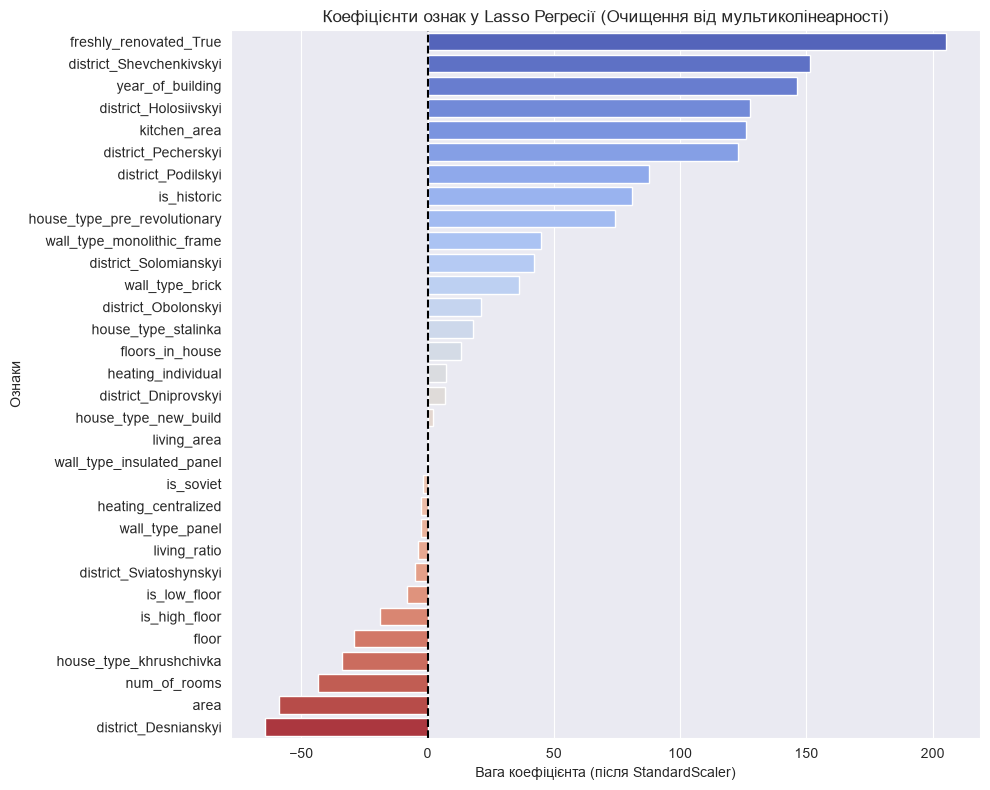


❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): ['living_area']


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==========================================
# 1. СТВОРЕННЯ ПАЙПЛАЙНІВ З МАСШТАБУВАННЯМ
# ==========================================

# Налаштовуємо сітку для параметра alpha (сила регуляризації)
param_grid = {'model__alpha': np.logspace(-3, 3, 13)}

# Пайплайн для Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

# Пайплайн для Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000)) # збільшено max_iter для збіжності
])

# ==========================================
# 2. ЗАПУСК GRID SEARCH ДЛЯ ОБОХ МОДЕЛЕЙ
# ==========================================

print("=== Оптимізація Ridge (L2)... ===")
ridge_grid = GridSearchCV(ridge_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print("=== Оптимізація Lasso (L1)... ===")
lasso_grid = GridSearchCV(lasso_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

# ==========================================
# 3. ОЦІНКА ТА ПОРІВНЯННЯ МЕТРИК
# ==========================================

ridge_preds = ridge_grid.predict(X_test)
lasso_preds = lasso_grid.predict(X_test)

print("\n=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===")
print(f"Ridge L2 -> Найкращий alpha: {ridge_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, ridge_preds):.4f} | MAE: ${mean_absolute_error(y_test, ridge_preds):.2f}")
print(f"Lasso L1 -> Найкращий alpha: {lasso_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, lasso_preds):.4f} | MAE: ${mean_absolute_error(y_test, lasso_preds):.2f}")

# ==========================================
# 4. ВІЗУАЛІЗАЦІЯ КОЕФІЦІЄНТІВ LASSO (ЯК ВОНА ЗАHУЛЯЄ ФІЧІ)
# ==========================================

best_lasso = lasso_grid.best_estimator_.named_steps['model']
lasso_coefs = pd.Series(best_lasso.coef_, index=X_train.columns).sort_values(ascending=False)

# Фільтруємо, щоб побачити тільки ненульові або топ-15 вагомих ознак
plt.figure(figsize=(10, 8))
sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, hue=lasso_coefs.index, palette="coolwarm", legend=False)
plt.title("Коефіцієнти ознак у Lasso Регресії (Очищення від мультиколінеарності)")
plt.xlabel("Вага коефіцієнта (після StandardScaler)")
plt.ylabel("Ознаки")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Виведемо список ознак, які Lasso повністю занулила
zeroed_features = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\n❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): {zeroed_features}")